In [4]:
# import libraries
import numpy as np
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt

In [5]:
def categorize_diffusers(diffuser_coordinates, fg_coordinates, k, max_distance=5):
    """"Returns arrays containing the types and chain indices of the k closest FGs for each diffuser.

    Args:
        diffuser_coordinates (np.array): a coordinates array of shape [n_diffusers, 3]
        fg_coordinates (Dictionary(string : np.array)): a coordinates dictionary of shape {fg_type : [n_chains, n_beads, 3]}
        k (int): Number of closest FGs to find for each diffuser
        
    Returns:
        np.array: Array of shape [n_diffusers, n] containing strings in format "<fg_type>_<chain_i>"
        or "cyt"/"nuc" if no FG is within max_distance.
    """
    n_diffusers = diffuser_coordinates.shape[0]
    # Initialize results array
    result = np.full((n_diffusers, k), "cyt", dtype='U20')
    result[diffuser_coordinates[:,2] < 0, :] = "nuc"
    
    # Pre-calculate total number of chains
    total_chains = sum(coords.shape[0] for coords in fg_coordinates.values())
    
    # Pre-allocate arrays for all chains
    all_min_distances = np.zeros((n_diffusers, total_chains))
    all_formatted_strings = np.empty(total_chains, dtype='U20')
    
    # Calculate minimum distances for all chains at once
    current_idx = 0
    for fg_type, coords in fg_coordinates.items():
        n_chains = coords.shape[0]
        
        # Generate formatted strings for this FG type
        chain_strings = np.array([f"{fg_type}_{i:02d}" for i in range(n_chains)])
        all_formatted_strings[current_idx:current_idx + n_chains] = chain_strings
        
        # Reshape arrays for broadcasting
        chains_reshaped = coords.reshape(n_chains, -1, 3)  # [n_chains, n_beads, 3]
        diffusers_expanded = diffuser_coordinates[:, np.newaxis, np.newaxis, :]  # [n_diffusers, 1, 1, 3]
        
        # Calculate distances to all beads for all chains at once
        distances = np.linalg.norm(chains_reshaped[np.newaxis, :, :, :] - diffusers_expanded, axis=3)
        
        # Find minimum distance per chain
        all_min_distances[:, current_idx:current_idx + n_chains] = np.min(distances, axis=2)
        
        current_idx += n_chains
    
    # Process each diffuser using vectorized operations
    for i in range(n_diffusers):
        # Find valid distances within max_distance
        valid_mask = all_min_distances[i] <= max_distance
        
        if np.any(valid_mask):
            # Get valid distances and their indices
            valid_distances = all_min_distances[i][valid_mask]
            valid_strings = all_formatted_strings[valid_mask]
            
            # Get indices of k smallest distances
            k_smallest_indices = np.argsort(valid_distances)[:k]
            result[i, :len(k_smallest_indices)] = valid_strings[k_smallest_indices]
    
    return result


def categorize_diffusers_over_time(diffuser_trajectories, fg_trajectories, k, step=1):
    n_diffusers = diffuser_trajectories.shape[0]
    n_t = diffuser_trajectories.shape[2]
    n_t2 = fg_trajectories["Nsp1"].shape[3]
    if n_t != n_t2:
        raise Exception("Times not matching")
    n_columns = len(range(0, n_t, step))
    categorized_trajectories = np.zeros(shape=(n_diffusers, k, n_columns), dtype='U20')
    for t in range(0, n_t, step):
        cur_diffuser_trajectories = diffuser_trajectories[:, :, t]
        cur_fg_trajectories = {fg_type : fg_trajectories[:, :, :, t] for (fg_type, fg_trajectories) in fg_trajectories.items()}
        categorized_trajectories[:,:,int(t / step)] = categorize_diffusers(cur_diffuser_trajectories, cur_fg_trajectories, k)
    return categorized_trajectories


def generate_transition_matrix(data):
    """
    Generate a transition matrix from an array of categorical time series.
    
    Parameters:
    -----------
    data : array-like
        Array of shape [n_diffusers, t] containing categorical data (strings)
        
    Returns:
    --------
    transition_matrix : numpy.ndarray
        Matrix of transition probabilities
    states : list
        List of unique states (categories)
    """
    # Get unique states
    states = sorted(list(set(data.flatten())))
    n_states = len(states)
    
    # Create state to index mapping
    state_to_idx = {state: idx for idx, state in enumerate(states)}
    
    # Initialize transition counts
    transition_counts = defaultdict(lambda: defaultdict(int))
    
    # Count transitions
    for sequence in data:
        for t in range(len(sequence) - 1):
            current_state = sequence[t]
            next_state = sequence[t + 1]
            transition_counts[current_state][next_state] += 1
    
    # Create transition matrix
    transition_matrix = np.zeros((n_states, n_states))
    
    # Fill transition matrix with probabilities
    for i, state_i in enumerate(states):
        total_transitions = sum(transition_counts[state_i].values())
        if total_transitions > 0:  # Avoid division by zero
            for j, state_j in enumerate(states):
                transition_matrix[i, j] = transition_counts[state_i][state_j] / total_transitions
    
    return transition_matrix, states

In [12]:
#############
# Load data #
#############
arrays = []
for i in range(1,2):
    with open(f"data/singles/{i}/110-160.pickle", "rb") as f:
        diffuser_trajectories = pickle.load(f)
    with open(f"data/singles/{i}/110-160-fgs.pickle", "rb") as f:
        fg_trajectories = pickle.load(f)
    arrays.append(categorize_diffusers_over_time(diffuser_trajectories, fg_trajectories, 1, step=1))
all = np.concatenate(arrays, axis=0)

#######################################
# Generate and save transition matrix #
#######################################
tm, states = generate_transition_matrix(all[:,0,:])
with open("data/transition_matrices/interactions_110-160.pickle", "wb") as f:
    pickle.dump((tm, states), f)

/tmp/ipykernel_3539168/4191027901.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(tm), cmap='jet', interpolation='nearest')


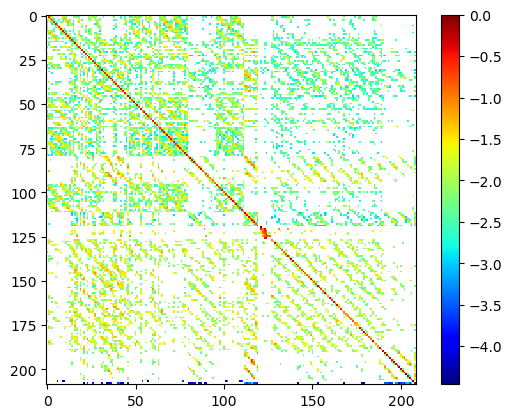

In [16]:
# Load and visualize transition matrix
with open("data/transition_matrices/interactions_110-160.pickle", "rb") as f:
    tm, states = pickle.load(f)


plt.imshow(np.log10(tm), cmap='jet', interpolation='nearest')
plt.colorbar()
plt.show()